<a href="https://colab.research.google.com/github/ZRodriguezq/ZRodriguezq/blob/main/Comas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Caso 1: Exploracion

In [27]:
import pandas as pd

datos = {
    "estudiante": ["Ana", "Luis", "Carlos", "Maria", "Pedro", "Lucia", "Jose", "Sofia"],
    "asistencia": [95, 70, 85, 90, 55, 80, 60, 98,],
    "nota": [18, 12, 15, 17, 9, 14, 10, 19]
}

df = pd.DataFrame(datos)

print(df)

  estudiante  asistencia  nota
0        Ana          95    18
1       Luis          70    12
2     Carlos          85    15
3      Maria          90    17
4      Pedro          55     9
5      Lucia          80    14
6       Jose          60    10
7      Sofia          98    19


In [28]:
print(df.head(7))

  estudiante  asistencia  nota
0        Ana          95    18
1       Luis          70    12
2     Carlos          85    15
3      Maria          90    17
4      Pedro          55     9
5      Lucia          80    14
6       Jose          60    10


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   estudiante  8 non-null      object
 1   asistencia  8 non-null      int64 
 2   nota        8 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 324.0+ bytes
None


In [ ]:
print(df.describe())

       asistencia       nota
count    8.000000   8.000000
mean    79.125000  14.250000
std     16.003906   3.693624
min     55.000000   9.000000
25%     67.500000  11.500000
50%     82.500000  14.500000
75%     91.250000  17.250000
max     98.000000  19.000000


In [ ]:
promedio = df["nota"].mean()

print(("Promedio:"), promedio)

Promedio: 14.25


In [ ]:
print("Nota máxima:", df["nota"].max())
print("Nota mínima:", df["nota"].min())

Nota máxima: 19
Nota mínima: 9


In [ ]:
aprobados = df[df["nota"] >= 11]

print(aprobados)

  estudiante  asistencia  nota
0        Ana          95    18
1       Luis          70    12
2     Carlos          85    15
3      Maria          90    17
5      Lucia          80    14
7      Sofia          98    19


In [ ]:
desaprobados = df[df["nota"] <= 10]

print(desaprobados)

  estudiante  asistencia  nota
4      Pedro          55     9
6       Jose          60    10


In [ ]:
riesgo = df[(df["nota"] < 11) | (df["asistencia"] < 70)]

print("Estudiantes en riesgo:")
print(riesgo)

Estudiantes en riesgo:
  estudiante  asistencia  nota
4      Pedro          55     9
6       Jose          60    10


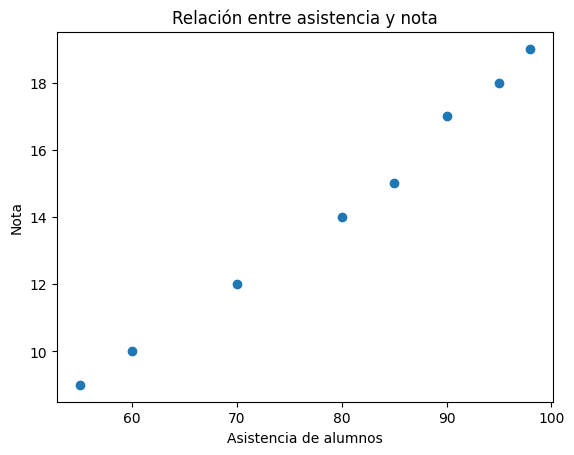

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["asistencia"], df["nota"])

plt.xlabel("Asistencia de alumnos")
plt.ylabel("Nota")
plt.title("Relación entre asistencia y nota")

plt.show()

In [ ]:
Caso 2: Limpieza

In [29]:
import pandas as pd
import numpy as np

datos = {
    "estudiante": ["Ana", "Luis", "Carlos", "Maria", "Pedro", "Ana"],
    "edad": [20, 21, np.nan, 22, 200, 20],
    "nota": [18, 15, np.nan, 17, 9, 18],
    "asistencia": [95, 80, 85, np.nan, 55, 95]
}

df = pd.DataFrame(datos)

print(df)

  estudiante   edad  nota  asistencia
0        Ana   20.0  18.0        95.0
1       Luis   21.0  15.0        80.0
2     Carlos    NaN   NaN        85.0
3      Maria   22.0  17.0         NaN
4      Pedro  200.0   9.0        55.0
5        Ana   20.0  18.0        95.0


In [ ]:
print(df.isnull().sum())

estudiante    0
edad          1
nota          1
asistencia    1
dtype: int64


In [ ]:
df = df.drop_duplicates()

print(df)

  estudiante   edad  nota  asistencia
0        Ana   20.0  18.0        95.0
1       Luis   21.0  15.0        80.0
2     Carlos    NaN   NaN        85.0
3      Maria   22.0  17.0         NaN
4      Pedro  200.0   9.0        55.0


In [ ]:
df.loc[df["edad"] > 100, "edad"] =np.nan

df = df.drop_duplicates()

print(df)

  estudiante  edad  nota  asistencia
0        Ana  20.0  18.0        95.0
1       Luis  21.0  15.0        80.0
2     Carlos   NaN   NaN        85.0
3      Maria  22.0  17.0         NaN
4      Pedro   NaN   9.0        55.0


In [ ]:
Caso 3: Prediccion

In [ ]:
import pandas as pd

datos = { "publicidad": [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
         "ventas": [1200, 1800, 2500, 3200, 3900, 4500, 5200, 6000, 6700, 7500]
}

df = pd.DataFrame(datos)

print(df)


   publicidad  ventas
0         100    1200
1         200    1800
2         300    2500
3         400    3200
4         500    3900
5         600    4500
6         700    5200
7         800    6000
8         900    6700
9        1000    7500


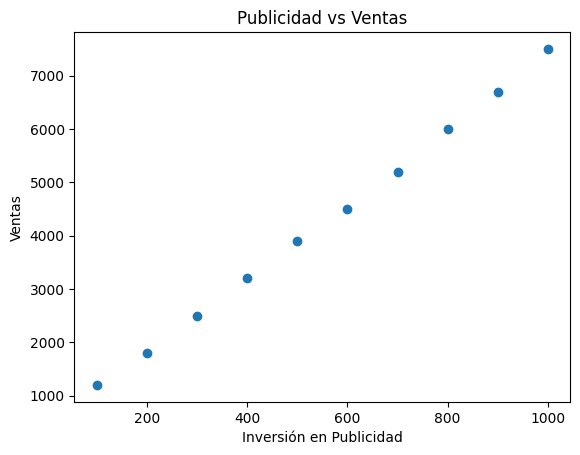

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    df["publicidad"],
    df["ventas"]
)

plt.xlabel("Inversión en Publicidad")
plt.ylabel("Ventas")
plt.title("Publicidad vs Ventas")

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[["publicidad"]]
y = df["ventas"]

modelo = LinearRegression()

modelo.fit(X, y)

LinearRegression()

In [ ]:
prediccion = modelo.predict([[1200]])

print("Ventas estimadas:")